=== BASELINE RANDOM FOREST ===
Accuracy: 0.8058
F1 Score: 0.8347
Runtime: 1.07 seconds
--------------------------------------------------
--- Tuning Parameter Set 1 ---
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.8058, F1 Score: 0.8347, Runtime: 9.8s

--- Tuning Parameter Set 2 ---
Best Params: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Accuracy: 0.801, F1 Score: 0.8327, Runtime: 63.96s

--- Tuning Parameter Set 3 ---
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 0.8058, F1 Score: 0.8347, Runtime: 3.82s



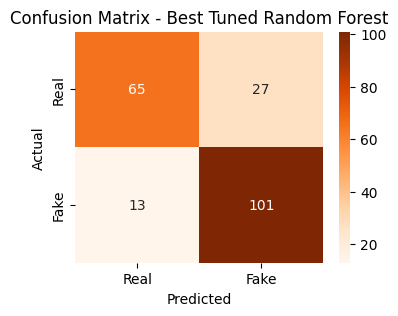


=== RANDOM FOREST MODEL COMPARISON ===
        Set                                        Best Params  Accuracy  \
0  Baseline                                            Default    0.8058   
1         1  {'max_depth': None, 'min_samples_leaf': 1, 'mi...    0.8058   
2         2  {'max_depth': 30, 'min_samples_leaf': 2, 'min_...    0.8010   
3         3  {'max_depth': None, 'min_samples_leaf': 2, 'mi...    0.8058   

   F1 Score  Runtime (s)  
0    0.8347         1.07  
1    0.8347         9.80  
2    0.8327        63.96  
3    0.8347         3.82  

=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===
[0.82352941 0.84153005 0.8125     0.85714286 0.78534031]
Mean F1 Score: 0.824


In [4]:
# MODEL 2: RANDOM FOREST

import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("final_preprocessed_vectorized.csv")

# Features and target
tfidf_cols = [c for c in df.columns if c.startswith('tfidf_')]
X = df[tfidf_cols]
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Baseline Random Forest
rf_base = RandomForestClassifier(random_state=42)
start = time.time()
rf_base.fit(X_train, y_train)
yp_base = rf_base.predict(X_test)
end = time.time()
baseline_runtime = round(end - start, 2)

print("=== BASELINE RANDOM FOREST ===")
print("Accuracy:", round(accuracy_score(y_test, yp_base),4))
print("F1 Score:", round(f1_score(y_test, yp_base),4))
print("Runtime:", baseline_runtime, "seconds")
print("-"*50)

#  Parameter tuning
param_sets = [
    {'n_estimators':[100,200], 'max_depth':[None,10], 'min_samples_split':[2], 'min_samples_leaf':[1]},
    {'n_estimators':[300,400], 'max_depth':[20,30], 'min_samples_split':[2,5], 'min_samples_leaf':[1,2]},
    {'n_estimators':[100,150], 'max_depth':[None], 'min_samples_split':[5], 'min_samples_leaf':[2]}
]

best_score = 0
best_model = None
best_params = None
tuning_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for i, params in enumerate(param_sets, 1):
    print(f"--- Tuning Parameter Set {i} ---")
    rf = RandomForestClassifier(random_state=42)
    start = time.time()
    grid = GridSearchCV(rf, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    end = time.time()
    runtime = round(end - start, 2)

    yp = grid.predict(X_test)
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp)

    tuning_results.append({
        'Set': i,
        'Best Params': grid.best_params_,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4),
        'Runtime (s)': runtime
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {round(acc,4)}, F1 Score: {round(f1,4)}, Runtime: {runtime}s\n")

    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_params = grid.best_params_

yp_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("Confusion Matrix - Best Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Model Comparison Table
comparison_df = pd.DataFrame(tuning_results)
baseline_row = pd.DataFrame([{
    'Set': 'Baseline',
    'Best Params': 'Default',
    'Accuracy': round(accuracy_score(y_test, yp_base),4),
    'F1 Score': round(f1_score(y_test, yp_base),4),
    'Runtime (s)': baseline_runtime
}])
comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print("\n=== RANDOM FOREST MODEL COMPARISON ===")
print(comparison_df)

#  Cross-validation on Best Tuned Model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
print("\n=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===")
print(cv_scores)
print("Mean F1 Score:", round(np.mean(cv_scores),4))